<style>
:root { --uw-navy:#17233c; --uw-amber:#c58a1a; --uw-cream:#fff7e6; --uw-blue:#2f6f9f; --uw-graphite:#384252; }
.jp-RenderedHTMLCommon h1 { color: var(--uw-navy); border-bottom: 4px double var(--uw-amber); padding-bottom: .35rem; }
.jp-RenderedHTMLCommon h2 { color: var(--uw-navy); margin-top: 1.7rem; }
.jp-RenderedHTMLCommon h3 { color: var(--uw-amber); }
.uw-ledger { background: linear-gradient(135deg, #17233c, #24385e); color: white; border-radius: 16px; padding: 20px 24px; box-shadow: 0 4px 16px rgba(23,35,60,.18); }
.uw-ledger h1 { color:white !important; border:0 !important; padding:0 !important; margin:.2rem 0 .5rem 0 !important; }
.uw-kicker { color:#ffd98a; font-weight:700; letter-spacing:.06em; text-transform:uppercase; font-size:.82rem; }
.uw-strip { display:flex; gap:12px; flex-wrap:wrap; margin-top:12px; }
.uw-pill { background:rgba(255,255,255,.10); border:1px solid rgba(255,255,255,.22); border-radius:999px; padding:8px 12px; }
</style>

<div class="uw-ledger">
  <div class="uw-kicker">Actuarial portfolio governance</div>
  <h1>Insurance Underwriting Governance Review</h1>
  <p style="margin:.2rem 0 .7rem 0;">HUG-IML decision-support evidence for material loss-cost triage, queue economics, proxy-risk review, and renewal-period stability.</p>
  <div class="uw-strip">
    <div class="uw-pill">Portfolio risk bands</div>
    <div class="uw-pill">Precision-governed referrals</div>
    <div class="uw-pill">Proxy and stability controls</div>
  </div>
</div>


## 1. Governance Scope

The model supports triage and review for underwriting and rate-governance workflows. It does not automate adverse actions by itself. Outcome fields such as claim count, claim amount, and annualized loss cost are used for validation and economic review, but they are excluded from model predictors to avoid leakage.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, precision_recall_curve, confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

from hugiml import HUGIMLClassifierNative

DATA_PATH = Path("nb09_insurance_underwriting_data.csv")
METADATA_PATH = Path("nb09_insurance_underwriting_metadata.csv")
OUTPUT_DIR = Path("nb09_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Visual identity for the underwriting portfolio review.
UW_NAVY = "#17233c"
UW_AMBER = "#c58a1a"
UW_BLUE = "#2f6f9f"
UW_CREAM = "#fff7e6"
UW_GRAPHITE = "#384252"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fffdf7",
    "axes.edgecolor": "#d7c49a",
    "axes.labelcolor": UW_GRAPHITE,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "xtick.color": UW_GRAPHITE,
    "ytick.color": UW_GRAPHITE,
    "grid.color": "#eadfca",
    "grid.alpha": 0.75,
})


## 2. Data Lineage and Field Register

The portfolio file includes policy attributes, claim outcomes, annualized loss cost, target flag, and renewal-period status. The field register identifies modeling eligibility and governance notes for each column.


In [2]:
df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH)

PREDICTORS = [
    "exposure", "area", "region", "vehicle_power", "vehicle_age",
    "driver_age", "bonus_malus", "density", "vehicle_brand"
]
TARGET = "material_loss_flag"
OUTCOME_FIELDS = ["claim_count", "claim_amount", "annualized_loss_cost"]
TRACE_FIELDS = ["policy_id"]

X = df[PREDICTORS].copy()
y = df[TARGET].astype(int)

display(pd.DataFrame({
    "policies": [len(df)],
    "predictors": [len(PREDICTORS)],
    "target_positive_rate": [y.mean()],
    "outcome_fields_excluded_from_predictors": [", ".join(OUTCOME_FIELDS)],
}))
display(metadata)


,policies,predictors,target_positive_rate,outcome_fields_excluded_from_predictors
0,18000,9,0.22,"claim_count, claim_amount, annualized_loss_cost"


,column_name,role,data_type,description,used_in_model,governance_note
0,policy_id,identifier,string,Synthetic policy identifier.,No,Excluded from modeling; audit traceability only.
1,exposure,predictor,numeric,Policy exposure period used to normalize claim...,Yes,Core actuarial context variable.
2,area,predictor,categorical,Territory-area grouping similar to motor insur...,Yes,Governance-sensitive; requires proxy-risk review.
3,region,predictor,categorical,Regional policy grouping.,Yes,Governance-sensitive geography variable.
4,vehicle_power,predictor,integer,Vehicle power class.,Yes,Actuarially recognizable vehicle-risk factor.
5,vehicle_age,predictor,numeric,Vehicle age in years.,Yes,Vehicle condition and replacement-cost proxy.
6,driver_age,predictor,integer,Driver age.,Yes,Governance-sensitive; requires jurisdiction-sp...
7,bonus_malus,predictor,numeric,Prior-risk / bonus-malus style risk index.,Yes,Strong actuarial risk signal.
8,density,predictor,numeric,Territory density / urbanicity proxy.,Yes,Governance-sensitive geography-related variable.
9,vehicle_brand,predictor,categorical,Vehicle brand grouping.,Yes,Rating factor; support and stability should be...


## 3. Data Quality, Leakage, and Segmentation Controls

The checks below confirm that model predictors are available, the target is binary, and leakage-prone outcomes are excluded from the modeling matrix. Geography and age-related variables are retained because they are common actuarial context fields, but they receive additional proxy-risk review.


In [3]:
quality = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "unique_values": df.nunique().values,
    "used_as_predictor": [c in PREDICTORS for c in df.columns],
})
controls = pd.DataFrame({
    "control": [
        "target is binary",
        "claim outcome fields excluded from predictors",
        "policy identifier excluded from predictors",
        "predictors have no missing values",
    ],
    "status": [
        "pass" if set(y.unique()).issubset({0, 1}) else "review",
        "pass" if not any(c in PREDICTORS for c in OUTCOME_FIELDS) else "review",
        "pass" if not any(c in PREDICTORS for c in TRACE_FIELDS) else "review",
        "pass" if int(X.isna().sum().sum()) == 0 else "review",
    ],
})
display(controls)
display(quality)
quality.to_csv(OUTPUT_DIR / "data_quality_register.csv", index=False)


,control,status
0,target is binary,pass
1,claim outcome fields excluded from predictors,pass
2,policy identifier excluded from predictors,pass
3,predictors have no missing values,pass


,column,dtype,missing_count,unique_values,used_as_predictor
0,policy_id,object,0,18000,False
1,exposure,float64,0,751,True
2,area,object,0,6,True
3,region,object,0,7,True
4,vehicle_power,int64,0,12,True
5,vehicle_age,float64,0,251,True
6,driver_age,int64,0,71,True
7,bonus_malus,int64,0,111,True
8,density,int64,0,3417,True
9,vehicle_brand,object,0,7,True


## 4. HUG-IML Model Development

HUG-IML is used as the modeling API so the retained signals are expressed as interpretable interval and category patterns. The split is stratified by the material-loss target.


In [4]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.30, random_state=23, stratify=y
)

int_cols = X_train.select_dtypes(include=["integer", "int"]).columns.tolist()
float_cols = X_train.select_dtypes(include=["float", "float64", "float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

clf = HUGIMLClassifierNative(
    allCols=[int_cols, float_cols, cat_cols],
    origColumns=PREDICTORS,
    B=10,
    L=2,
    G=0.00005,
    topK=120,
    adaptive_binning=True,
    b_candidates=[6, 8, 10, 12],
    n_jobs=1,
)
clf.fit(X_train, y_train)
scores = clf.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "training_policies": [len(X_train)],
    "holdout_policies": [len(X_test)],
    "hug_patterns_retained": [len(clf.get_hug_features())],
    "integer_predictors": [len(int_cols)],
    "float_predictors": [len(float_cols)],
    "categorical_predictors": [len(cat_cols)],
})


,training_policies,holdout_policies,hug_patterns_retained,integer_predictors,float_predictors,categorical_predictors
0,12600,5400,57,4,2,3


## 5. Governed Threshold and Holdout Metrics

The threshold prioritizes precision so that rate-action and referral queues remain operationally credible. If the precision constraint cannot be met, the fallback within the threshold-selection rule maximizes F1 on the precision-recall curve.


In [5]:
def choose_threshold(y_true, y_score, min_precision=0.78):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    valid = np.where(precision[:-1] >= min_precision)[0]
    if len(valid):
        return float(thresholds[valid[np.argmax(recall[:-1][valid])]])
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[np.argmax(f1)])

threshold = choose_threshold(y_test, scores, min_precision=0.78)
pred = (scores >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

metrics = pd.Series({
    "roc_auc": roc_auc_score(y_test, scores),
    "average_precision": average_precision_score(y_test, scores),
    "precision_at_threshold": precision_score(y_test, pred, zero_division=0),
    "recall_at_threshold": recall_score(y_test, pred, zero_division=0),
    "f1_at_threshold": f1_score(y_test, pred, zero_division=0),
    "specificity_at_threshold": tn / max(tn + fp, 1),
    "threshold": threshold,
    "review_rate": pred.mean(),
    "false_positive_count": fp,
    "false_negative_count": fn,
}).to_frame("value")
confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual_not_flagged", "actual_material_loss"],
    columns=["predicted_not_referred", "predicted_referred"],
)
display(metrics)
display(confusion)
metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv")
confusion.to_csv(OUTPUT_DIR / "confusion_matrix.csv")


,value
roc_auc,0.941431
average_precision,0.837721
precision_at_threshold,0.780488
recall_at_threshold,0.700337
f1_at_threshold,0.738243
specificity_at_threshold,0.944444
threshold,0.481749
review_rate,0.197407
false_positive_count,234.000000
false_negative_count,356.000000


,predicted_not_referred,predicted_referred
actual_not_flagged,3978,234
actual_material_loss,356,832


## 6. Precision-Recall Profile

The curve shows the trade-off between queue precision and capture rate for material-loss policies. The marker indicates the governed operating threshold.


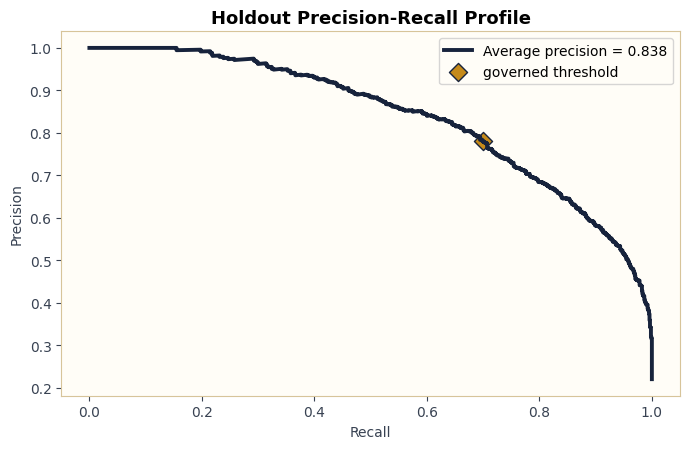

In [6]:
precision, recall, thresholds = precision_recall_curve(y_test, scores)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(recall, precision, color=UW_NAVY, linewidth=2.8, label=f"Average precision = {average_precision_score(y_test, scores):.3f}")
ax.scatter([recall_score(y_test, pred, zero_division=0)], [precision_score(y_test, pred, zero_division=0)], marker="D", s=85, color=UW_AMBER, edgecolor=UW_NAVY, label="governed threshold")
ax.set_title("Holdout Precision-Recall Profile")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "precision_recall_profile.png", dpi=180)
plt.show()


## 7. Risk-Band Economic Evidence

Policies are grouped by predicted risk score. Economic validation checks whether the model's higher-risk queues correspond to higher observed material-loss rates and higher annualized loss cost.


,risk_band,policies,exposure,claim_rate,observed_material_loss,avg_score,referral_rate,loss_cost,mean_claim_amount,loss_relativity
0,Core book,2700,1687.100,0.050370,0.007778,0.012997,0.000000,330.612404,211.223389,1.000000
1,Watch list,1350,840.879,0.080741,0.169630,0.153511,0.000000,966.472911,568.446156,2.923281
2,Elevated,810,506.721,0.127160,0.541975,0.553856,0.649383,1837.703259,1239.699716,5.558482
3,Rate action,378,228.490,0.137566,0.891534,0.887328,1.000000,2720.749286,1764.802593,8.229423
4,Referral,162,97.728,0.172840,1.000000,0.986564,1.000000,4055.747099,2347.594938,12.267377


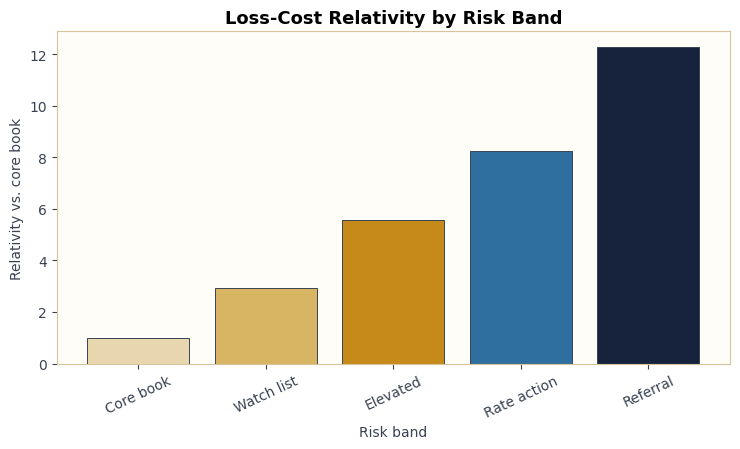

In [7]:
holdout = df.loc[idx_test].copy()
holdout["score"] = scores
holdout["prediction"] = pred
holdout["actual"] = y_test.values
holdout["risk_band"] = pd.qcut(
    holdout["score"],
    q=[0, 0.50, 0.75, 0.90, 0.97, 1.0],
    labels=["Core book", "Watch list", "Elevated", "Rate action", "Referral"],
    duplicates="drop",
)

band_summary = holdout.groupby("risk_band", observed=True).agg(
    policies=("policy_id", "count"),
    exposure=("exposure", "sum"),
    claim_rate=("claim_count", lambda s: (s > 0).mean()),
    observed_material_loss=("actual", "mean"),
    avg_score=("score", "mean"),
    referral_rate=("prediction", "mean"),
    loss_cost=("annualized_loss_cost", "mean"),
    mean_claim_amount=("claim_amount", "mean"),
).reset_index()
band_summary["loss_relativity"] = band_summary["loss_cost"] / band_summary["loss_cost"].iloc[0]
display(band_summary)
band_summary.to_csv(OUTPUT_DIR / "risk_band_economic_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
band_colors = ["#e8d7ae", "#d8b563", UW_AMBER, UW_BLUE, UW_NAVY][:len(band_summary)]
ax.bar(band_summary["risk_band"].astype(str), band_summary["loss_relativity"], color=band_colors, edgecolor=UW_GRAPHITE, linewidth=.7)
ax.set_title("Loss-Cost Relativity by Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Relativity vs. core book")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "risk_band_loss_relativity.png", dpi=180)
plt.show()


## 8. Proxy-Risk Review

Age, region, and area can affect underwriting outcomes and review burden. These summaries help governance teams check whether referral rates materially exceed observed loss patterns in particular segments.


In [8]:
holdout["age_band"] = pd.cut(
    holdout["driver_age"],
    bins=[17, 25, 35, 55, 70, 90],
    labels=["18-24", "25-34", "35-54", "55-69", "70+"],
)
age_summary = holdout.groupby("age_band", observed=True).agg(
    policies=("policy_id", "count"),
    review_rate=("prediction", "mean"),
    observed_loss=("actual", "mean"),
    avg_score=("score", "mean"),
    loss_cost=("annualized_loss_cost", "mean"),
).reset_index()
area_summary = holdout.groupby("area", observed=True).agg(
    policies=("policy_id", "count"),
    review_rate=("prediction", "mean"),
    observed_loss=("actual", "mean"),
    avg_score=("score", "mean"),
    loss_cost=("annualized_loss_cost", "mean"),
).reset_index().sort_values("review_rate", ascending=False)
region_summary = holdout.groupby("region", observed=True).agg(
    policies=("policy_id", "count"),
    review_rate=("prediction", "mean"),
    observed_loss=("actual", "mean"),
    avg_score=("score", "mean"),
    loss_cost=("annualized_loss_cost", "mean"),
).reset_index().sort_values("review_rate", ascending=False)

display(age_summary)
display(area_summary)
display(region_summary)
age_summary.to_csv(OUTPUT_DIR / "age_band_proxy_review.csv", index=False)
area_summary.to_csv(OUTPUT_DIR / "area_proxy_review.csv", index=False)
region_summary.to_csv(OUTPUT_DIR / "region_proxy_review.csv", index=False)


,age_band,policies,review_rate,observed_loss,avg_score,loss_cost
0,18-24,578,0.325260,0.359862,0.332454,1302.597526
1,25-34,966,0.193582,0.221532,0.215418,876.707340
2,35-54,2672,0.169910,0.188623,0.194077,713.364450
3,55-69,976,0.200820,0.204918,0.222610,1127.203668
4,70+,208,0.197115,0.298077,0.240833,3679.541202


,area,policies,review_rate,observed_loss,avg_score,loss_cost
5,F,540,0.505556,0.518519,0.500445,2175.495481
4,E,763,0.351245,0.353866,0.368609,1147.162818
3,D,1001,0.222777,0.273726,0.255781,1135.843147
2,C,1311,0.146453,0.155606,0.166118,806.023898
1,B,1045,0.076555,0.106220,0.108886,631.334804
0,A,740,0.040541,0.066216,0.063644,632.340324


,region,policies,review_rate,observed_loss,avg_score,loss_cost
3,Metro,977,0.348004,0.340839,0.361597,1296.774575
1,Coastal,554,0.259928,0.259928,0.267973,1507.753700
2,East,756,0.165344,0.198413,0.191356,804.862937
6,West,771,0.163424,0.195850,0.191982,922.229274
5,South,779,0.163030,0.200257,0.183983,1023.360475
0,Central,711,0.132208,0.168776,0.160984,739.061589
4,North,852,0.129108,0.157277,0.157258,735.887042


## 9. Renewal-Period Stability Review

The renewal-period split gives a simple stability check: scores and referral rates should remain explainable across current and prior-year records rather than depending on a single period.


In [9]:
renewal_summary = holdout.groupby("renewal_period", observed=True).agg(
    policies=("policy_id", "count"),
    review_rate=("prediction", "mean"),
    observed_loss=("actual", "mean"),
    avg_score=("score", "mean"),
    loss_cost=("annualized_loss_cost", "mean"),
).reset_index()
display(renewal_summary)
renewal_summary.to_csv(OUTPUT_DIR / "renewal_period_stability_review.csv", index=False)


,renewal_period,policies,review_rate,observed_loss,avg_score,loss_cost
0,Current Year,2554,0.203994,0.229444,0.224634,969.265775
1,Prior Year,2846,0.191497,0.211525,0.215205,1017.533742


## 10. HUG-IML Pattern Evidence

The retained HUG-IML patterns provide interpretable evidence for model review. Positive coefficients increase the material-loss score; negative coefficients reduce it.


,pattern,coefficient,abs_coefficient
0,"bonus_malus=[104,161)",3.512156,3.512156
1,"bonus_malus=[50,53)",-2.825457,2.825457
2,area=A,-2.663657,2.663657
3,area=F,2.500702,2.500702
4,"density=[7,164)",-2.270484,2.270484
5,"density=[1531,3.48e+04)",2.221263,2.221263
6,"bonus_malus=[53,61)",-1.946651,1.946651
7,"bonus_malus=[93,104)",1.854337,1.854337
8,area=B,-1.658397,1.658397
9,"driver_age=[18,25)",1.464006,1.464006


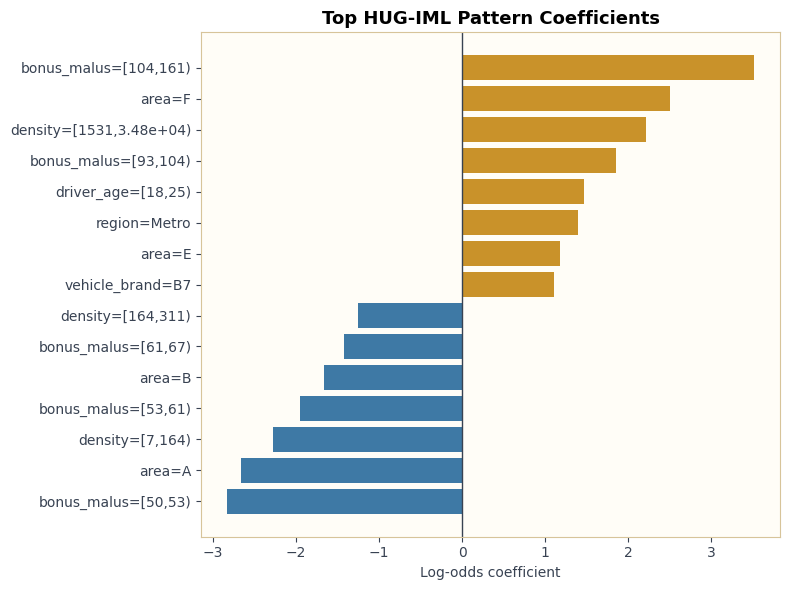

In [10]:
patterns = pd.DataFrame({
    "pattern": clf.get_hug_features(),
    "coefficient": clf.model_.named_steps["clf"].coef_[0],
})
patterns["abs_coefficient"] = patterns["coefficient"].abs()
patterns = patterns.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
patterns.to_csv(OUTPUT_DIR / "hugiml_pattern_register.csv", index=False)
display(patterns.head(25))

fig, ax = plt.subplots(figsize=(8, 6))
top_patterns = patterns.head(15).sort_values("coefficient")
coef_colors = [UW_AMBER if v > 0 else UW_BLUE for v in top_patterns["coefficient"]]
ax.barh(top_patterns["pattern"], top_patterns["coefficient"], color=coef_colors, alpha=.93)
ax.axvline(0, color=UW_GRAPHITE, linewidth=1)
ax.set_title("Top HUG-IML Pattern Coefficients")
ax.set_xlabel("Log-odds coefficient")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "top_pattern_coefficients.png", dpi=180)
plt.show()


## 11. Audit Artifacts

The exported artifacts summarize validation performance, threshold behavior, risk-band economics, proxy-risk review, retained HUG-IML patterns, and holdout policy-level scores.


In [11]:
holdout_scores = holdout[[
    "policy_id", "renewal_period", "score", "prediction", "actual", "risk_band",
    "area", "region", "driver_age", "age_band", "annualized_loss_cost", "claim_count", "claim_amount"
]].copy()
holdout_scores.to_csv(OUTPUT_DIR / "holdout_underwriting_scores.csv", index=False)

summary_payload = {
    "model_name": "hugiml-core HUGIMLClassifierNative",
    "policies": int(len(df)),
    "predictors": PREDICTORS,
    "target_definition": "material_loss_flag = 1 for materially high loss-cost segment",
    "roc_auc": float(roc_auc_score(y_test, scores)),
    "average_precision": float(average_precision_score(y_test, scores)),
    "precision_at_threshold": float(precision_score(y_test, pred, zero_division=0)),
    "recall_at_threshold": float(recall_score(y_test, pred, zero_division=0)),
    "f1_at_threshold": float(f1_score(y_test, pred, zero_division=0)),
    "threshold": float(threshold),
    "review_rate": float(pred.mean()),
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "pattern_count": int(len(patterns)),
    "leakage_control": "claim_count, claim_amount, and annualized_loss_cost excluded from predictors",
}
(OUTPUT_DIR / "underwriting_governance_summary.json").write_text(json.dumps(summary_payload, indent=2))
display(pd.Series(summary_payload, name="value").to_frame())


,value
model_name,hugiml-core HUGIMLClassifierNative
policies,18000
predictors,"[exposure, area, region, vehicle_power, vehicl..."
target_definition,material_loss_flag = 1 for materially high los...
roc_auc,0.941431
average_precision,0.837721
precision_at_threshold,0.780488
recall_at_threshold,0.700337
f1_at_threshold,0.738243
threshold,0.481749
